# Python & stats basics on ON & OFF RGCs

**author**: **laquitainesteeve@gmail.com**

**Week 2, Day 1**

**Learning outcomes:**
- Know how to use <u>Python Variables</u>, <u>data structure</u>, <u>functions</u>, <u>library import</u>, <u>debugging</u>, <u>documentation</u>
- Know how to use <u>Visualisation</u> with <u>matplotlib</u>
- Know how to use <u>Descriptive statistics</u>: group comparison with <u>non parametric hypothesis testing</u> such as <u>Mann-Whitney U test</u>, relationship between variabkes with <u>Pearson correlation</u>.

**A real dataset from the lab**:
- a full field stimulus
- spike counts of an ON RGC cell
- spike counts of an OFF RGC cell


## Check python setup

### Check Python is installed

In [ ]:
# print the version of python installed
!python --version

Python 3.12.13


### Import python libraries

In [ ]:
import numpy as np                    # numerical computing
import matplotlib.pyplot as plt       # plotting
from scipy.io import loadmat          # loading MATLAB .mat files
from numpy.linalg import inv          # matrix inversion

### Setup visualization parameters

In [ ]:
# Remove top and right spines from all figures for a cleaner look
plt.rcParams.update({'font.size': 14, 'axes.spines.top': False, 'axes.spines.right': False})

# setup 7-color palette
MAT_COL = [
    '#1f77b4',  # color 1 — blue       (training data)
    '#d62728',  # color 2 — red/orange (testing data)
    '#e6ac1f',  # color 3 — yellow     (linear filter / linear model)
    '#7d3c98',  # color 4 — purple     (full autocorr correction)
    '#77b51b',  # color 5 — green      (LN exp model)
    '#4dbfee',  # color 6 — light blue (LN exp + regularisation)
    '#a31232',  # color 7 — dark red   (LN softplus model)
]

## Describe data

### Access dataset

In [ ]:
# Mount Google Drive so we can access data files stored there
from google.colab import drive
drive.mount('/content/drive')

### Load data

In [ ]:
# Load the MATLAB data file — adapt the path to match your Drive folder structure
from scipy.io import loadmat
data = loadmat('/content/drive/MyDrive/ENSTA/dataset.mat')

### Data structure

#### Dictionary

- the data are stored in a **dictionary**.
- A dictionary is a **data structure**
- It contains paired **keys** and **values**

In [ ]:
# print data structure type of the data
print("- Data structure:", type(data))

# print its keys
print("- Dictionary keys:", data.keys())

# print its keys
print("- Dictionary values type:", type(data['stim']))

- Data structure: <class 'dict'>
- Dictionary keys: dict_keys(['__header__', '__version__', '__globals__', 'binnedOFF', 'binnedON', 'dt', 'stim'])
- Dictionary values type: <class 'numpy.ndarray'>


#### Data description

The dictionary contains:
- `binnedOFF`: spike counts of an OFF retinal ganglion cell
  - shape `(R, T)`, where:
    - R = repetitions
    - T = time bins  
- `binnedON` : spike counts of an ON retinal ganglion cell  
- `stim`     :
   - full-field flickering light — a single luminance value that changes over time, presented uniformly across the entire visual field (no spatial structure).
  - visual stimulus (luminance over time) — shape `(T,)`  
- `dt`       : bin width in seconds  


In [ ]:
# Extract each variable from the dictionary
binnedOFF = data['binnedOFF']       # OFF-cell spike counts,  shape (R, T)
binnedON  = data['binnedON']        # ON-cell spike counts,   shape (R, T)
stim      = data['stim'].ravel()    # visual stimulus,        shape (T,)
dt        = float(data['dt'])        # time-bin width in seconds

/tmp/ipykernel_539/295874790.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dt        = float(data['dt'])        # time-bin width in seconds


#### Space, time complexity

Which data structure to use? When?

- **dictionaries** are the right structure when you need
  - to store different data structures
  - **fast lookup** (cell ID, stimulus frame index, neuron type)

| Operation | Average case |
|---|---|
| `d[key]` (lookup) | O(1) |
| `d[key] = val` (insert) | O(1) |
| `del d[key]` (delete) | O(1) |
| `key in d` (membership) | O(1) |

- **numpy arrays** are right when you need fast vectorised computation, as we will.

| Operation | Average case |
|---|---|
| `a[i]` (index lookup) | O(1) |
| `a.append(x)` (insert at end) | O(1) amortized |
| `a.insert(i, x)` (insert at index) | O(n) |
| `del a[i]` (delete at index) | O(n) |
| `x in a` (membership) | O(n) |
| `a[i:j]` (slice) | O(k) |
| `len(a)` (length) | O(1) |

### Statistics & Visualization


We will use the "Matplotlib" library for data visualization.



#### plot(): line plot

Visualize the luminance of the full-field stimulus in the key "stim".

##### plot stimulus luminance

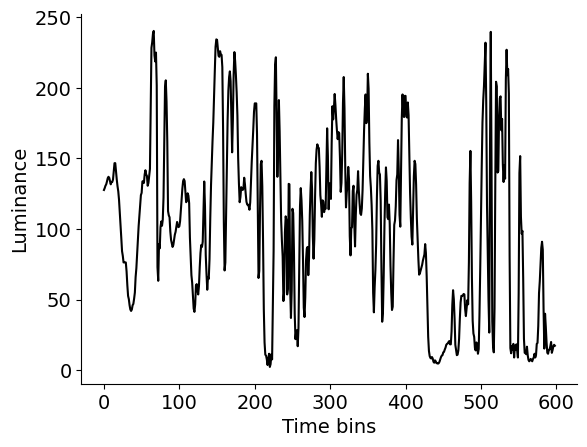

In [ ]:
# import visualization library
from matplotlib import pyplot as plt

# plot the full-field stimulus luminance
plt.plot(stim, color='k');

# annotate x axis
plt.xlabel('Time bins');

# annotate y axis
plt.ylabel('Luminance');

##### plot mean of RGC responses

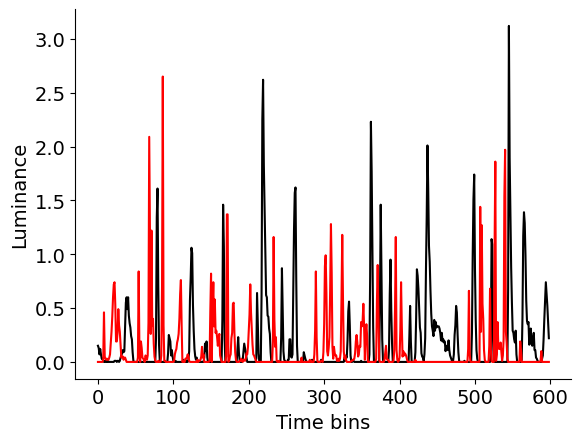

In [ ]:
# calculate the mean of the RGCs' responses over repetitions
mean_off_response = np.mean(binnedOFF, axis=0) # OFF neuron
mean_on_response = np.mean(binnedON, axis=0) # ON neuron

# plot the full-field stimulus luminance
plt.plot(mean_off_response, color='k'); # OFF neuron
plt.plot(mean_on_response, color='r'); # ON neuron

# annotate x axis
plt.xlabel('Time bins');

# annotate y axis
plt.ylabel('Luminance');

##### plot variance of RGC responses

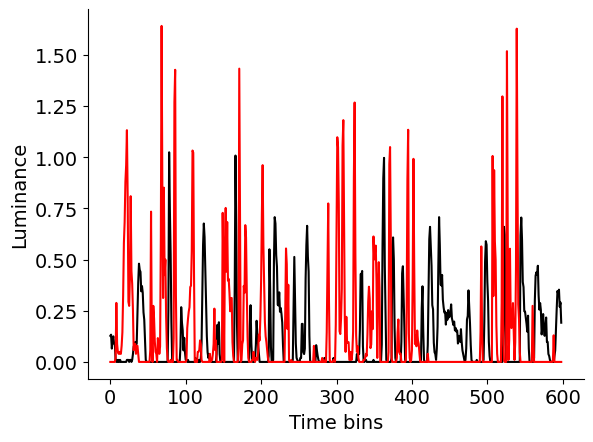

In [ ]:
# calculate the mean of the RGCs' responses over repetitions
var_off_response = np.var(binnedOFF, axis=0) # OFF neuron
var_on_response = np.var(binnedON, axis=0) # ON neuron

# plot the full-field stimulus luminance
plt.plot(var_off_response, color='k'); # OFF neuron
plt.plot(var_on_response, color='r'); # ON neuron

# annotate x axis
plt.xlabel('Time bins');

# annotate y axis
plt.ylabel('Luminance');

#### Hist(): distributions of RGC responses

**Why this matters?**
- We test here the popular assumption that neurons' spike counts responses are Poisson distributed.
- We WILL use that assumption to model neural responses later.

**Visualization**

- We plot the distribution of spike counts evoked by the repetition of the same stimulus (same luminance, "binnedOFF" data at time bin 0 (col)) for an OFF RGC cell.

**Conclusion**
- The spike count mean is close to its variance.
- A Poisson distribution with the same mean as the mean spike counts qualitatively fits well the spike count distribution.
- The Spike counts of the OFF RGC are Poisson distributed.


- Mean:     0.6300
- Variance: 0.4931
Ratio (should be 1 if Poisson): 0.7827


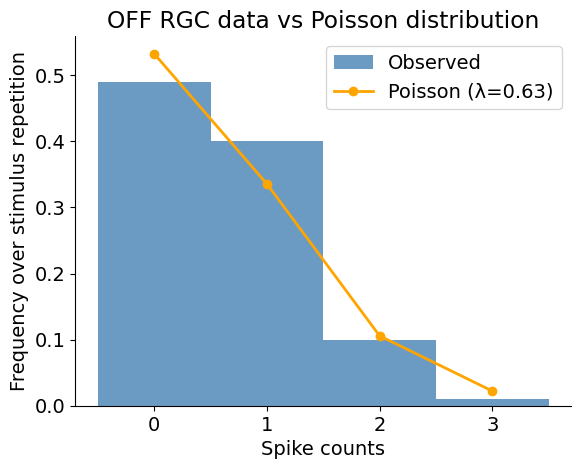

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, chi2_contingency

# select a time bin index
time_bin_idx = 217

# get spike counts
counts = binnedOFF[:, time_bin_idx]

# Data distribution
unique, observed = np.unique(counts, return_counts=True)
data_freq = observed / observed.sum()

# Fit Poisson: MLE estimate is just the mean
lambda_hat = counts.mean()
print(f"- Mean:     {lambda_hat:.4f}")
print(f"- Variance: {counts.var():.4f}")
print(f"Ratio (should be 1 if Poisson): {counts.var() / lambda_hat:.4f}")

# Expected Poisson frequencies
expected_freq = poisson.pmf(unique, lambda_hat)

# Plot
fig, ax = plt.subplots(1,1)

# Histogram comparison
x_range = np.arange(0, counts.max() + 1)

# line plot
# - OFF RGC data as bars
ax.hist(counts, bins=np.arange(counts.max() + 2) - 0.5, density=True,
        label='Observed', color='steelblue', alpha=0.8)

# - Poisson as line
ax.plot(x_range, poisson.pmf(x_range, lambda_hat),
        'o-', color='orange', linewidth=2, markersize=6,
        label=f'Poisson (λ={lambda_hat:.2f})')

# annotate axes
ax.set_xlabel("""Spike counts""")
ax.set_ylabel('Frequency over stimulus repetition')
ax.set_title('OFF RGC data vs Poisson distribution')

# annotate legend
ax.legend()

#### Define/Use functions

**Why this matter?**

- **Reusability** — write once, call many times. Instead of copy-pasting the Poisson plot code for ON and OFF cells, you call plot_poisson_fit(binnedON) and plot_poisson_fit(binnedOFF).

- **Readability** — a well-named function like plot_stim(stim) tells you exactly what the code does without reading the implementation. Your pipeline reads like prose.

- **Testability** — you can verify a function works correctly on a simple known input before running it on real data. Hard to do with inline code.

- **Modularity** — changing the binning strategy or the fit method in one place updates all downstream analyses automatically.

- **Abstraction** — you can use a function without understanding the linear algebra inside it, then later open the function to learn how it works.

In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, chi2_contingency

def plot_stim(ax, stim: np.array):
  """plot the stimulus

  Args:
    stim (np.array): a full-field stimulus luminance
  """
  # plot the full-field stimulus luminance
  ax.plot(stim, color='k');

  # annotate x axis
  ax.set_xlabel('Time bins');

  # annotate y axis
  ax.set_ylabel('Luminance');


def plot_poisson_fit(ax, cell: np.array, counts: np.array, time_bin_idx=217, title:str="", xlim=(0,4)):

  # get spike counts
  counts = cell[:, time_bin_idx]

  # Data distribution
  unique, observed = np.unique(counts, return_counts=True)
  data_freq = observed / observed.sum()

  # Fit Poisson: MLE estimate is just the mean
  lambda_hat = counts.mean()
  print(f"- Mean:     {lambda_hat:.4f}")
  print(f"- Variance: {counts.var():.4f}")
  print(f"Ratio (should be 1 if Poisson): {counts.var() / lambda_hat:.4f}")

  # Expected Poisson frequencies
  expected_freq = poisson.pmf(unique, lambda_hat)

  # Histogram comparison
  x_range = np.arange(0, counts.max() + 1)

  # line plot
  # - OFF RGC data as bars
  ax.hist(counts, bins=np.arange(counts.max() + 2) - 0.5, density=True,
          label='Observed', color='steelblue', alpha=0.8)

  # - Poisson as line
  ax.plot(x_range, poisson.pmf(x_range, lambda_hat),
          'o-', color='orange', linewidth=2, markersize=6,
          label=f'Poisson (λ={lambda_hat:.2f})')

  # annotate axes
  ax.set_xlabel("""Spike counts""")
  ax.set_ylabel('Frequency over stimulus repetition')
  ax.set_title(title)

  # limits of xaxis
  ax.set_xlim(xlim)

  # annotate legend
  ax.legend()

### Test statistical hypotheses

**Question**:
- Do OFF cells spike more than ON cells at low luminance?
- Do ON cells spike more than OFF cells at high luminance?

**Null hypothesis**: OFF cells spike as much as ON cells at low luminance.

The stimulus luminance is very low at bin index 217 and very high at 154.

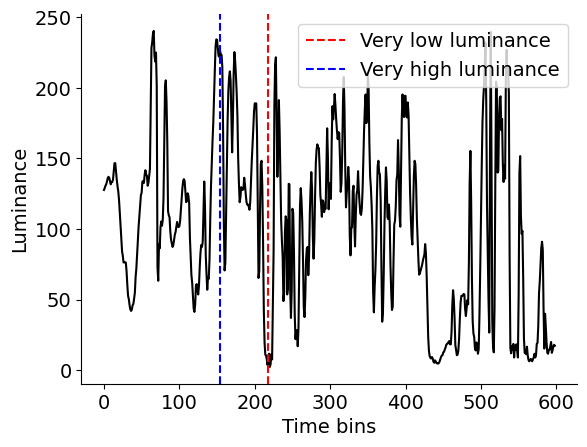

In [ ]:
fig, ax = plt.subplots(1,1)

# plot the stimulus
plot_stim(ax, stim)

# time bin of low luminance
time_bin_idx_low = 217

# plot a vertical line at a time bin of very low stimulus luminance
ax.axvline(time_bin_idx_low, color='red', linestyle='--', linewidth=1.5, label=f'Very low luminance');

# time bin of high luminance
time_bin_idx_high = 154

# plot a vertical line at a time bin of very low stimulus luminance
ax.axvline(time_bin_idx_high, color='blue', linestyle='--', linewidth=1.5, label=f'Very high luminance');

# annotate legend
plt.legend();

#### Distribution of responses at low luminance

- Mean:     0.6300
- Variance: 0.4931
Ratio (should be 1 if Poisson): 0.7827
- Mean:     0.0000
- Variance: 0.0000
Ratio (should be 1 if Poisson): nan


/tmp/ipykernel_539/2280444216.py:35: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Ratio (should be 1 if Poisson): {counts.var() / lambda_hat:.4f}")


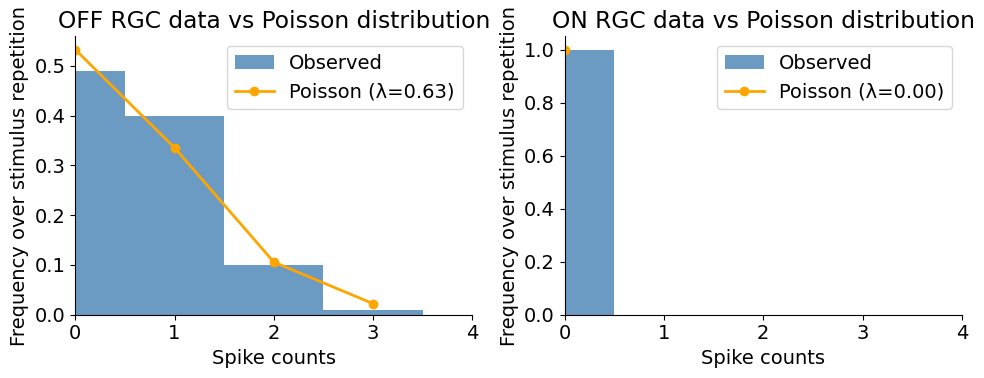

In [ ]:
# Plot
fig, ax = plt.subplots(1,2, figsize=(10,4))

# plot distribution of OFF RGC responses at time bin of low stimulus luminance
plot_poisson_fit(ax[0], binnedOFF, counts, time_bin_idx=time_bin_idx, title='OFF RGC data vs Poisson distribution')

# plot distribution of ON RGC responses
plot_poisson_fit(ax[1], binnedON, counts, time_bin_idx=time_bin_idx, title='ON RGC data vs Poisson distribution')

plt.tight_layout()

#### Distribution of responses at high luminance

- Mean:     0.0000
- Variance: 0.0000
Ratio (should be 1 if Poisson): nan
- Mean:     0.3300
- Variance: 0.4411
Ratio (should be 1 if Poisson): 1.3367


/tmp/ipykernel_539/2280444216.py:35: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Ratio (should be 1 if Poisson): {counts.var() / lambda_hat:.4f}")


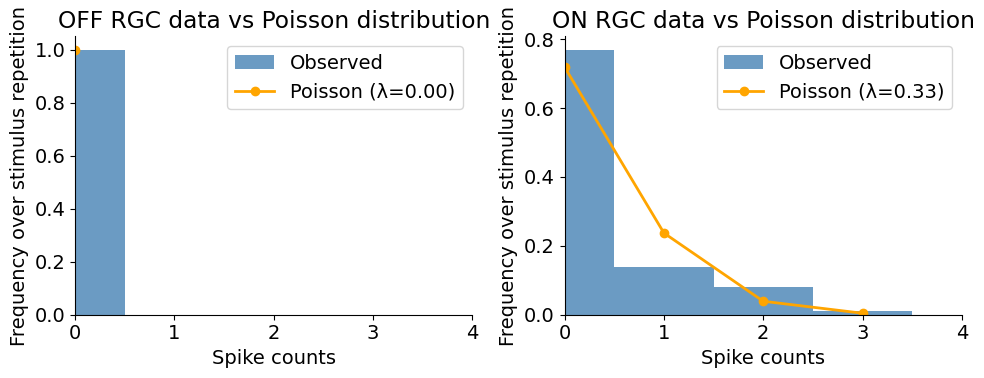

In [ ]:
# Plot
fig, ax = plt.subplots(1,2, figsize=(10,4))

# plot distribution of OFF RGC responses at time bin of low stimulus luminance
plot_poisson_fit(ax[0], binnedOFF, counts, time_bin_idx=time_bin_idx, title='OFF RGC data vs Poisson distribution')

# plot distribution of ON RGC responses
plot_poisson_fit(ax[1], binnedON, counts, time_bin_idx=time_bin_idx, title='ON RGC data vs Poisson distribution')

plt.tight_layout()

#### Choose a statistical test

**Decision tree**:

* Both groups normal AND equal variances?

    ├── YES → **t-test** (equivalent to ANOVA with 2 groups)  
    ├── Normal but unequal variances → **Welch t-test**  
    └── NOT normal → **Mann-Whitney U** (non-parametric)


  --> choose **Mann-Whitney U** as responses are Poisson distributed.

* **Conclusion**:   
  * p-value is 0.0000.
    * p = probability of observing a test statistic as extreme as U=7550.0 (or more), assuming OFF and ON cells are drawn from the same distribution.
    * This means that If OFF and ON cells had the same spike count distribution, we would observe a difference this large or larger with probability ≈ 0. We therefore reject the null hypothesis -> OFF RGCs fire more than ON cells at low luminance

#### OFF RGCs fire more than ON at low luminance

In [ ]:
# import mannwhitneyu library
from scipy.stats import mannwhitneyu

# Test if OFF cells spike MORE than ON cells at low luminance
stat, p = mannwhitneyu(binnedOFF[:, time_bin_idx], binnedON[:, time_bin_idx], alternative='greater')

# report statistics
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"p-value: {p:.4f}")

Mann-Whitney U statistic: 7550.0
p-value: 0.0000


#### ON RGCs fire more than OFF at high luminance

In [ ]:
# import mannwhitneyu library
from scipy.stats import mannwhitneyu

# Test if OFF cells spike MORE than ON cells at low luminance
stat, p = mannwhitneyu(binnedON[:, time_bin_idx], binnedOFF[:, time_bin_idx], alternative='greater')

# report statistics
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"p-value: {p:.4f}")

Mann-Whitney U statistic: 6150.0
p-value: 0.0000


#### Tests relationship between luminance and response

**Question**:

- Are ON cells responses **positively correlated** with stimulus luminance?

- Are OFF cells **anti-correlated** with stimulus luminance?

**Null hypothesis**: OFF and ON cells are not correlated with stimulus luminance.

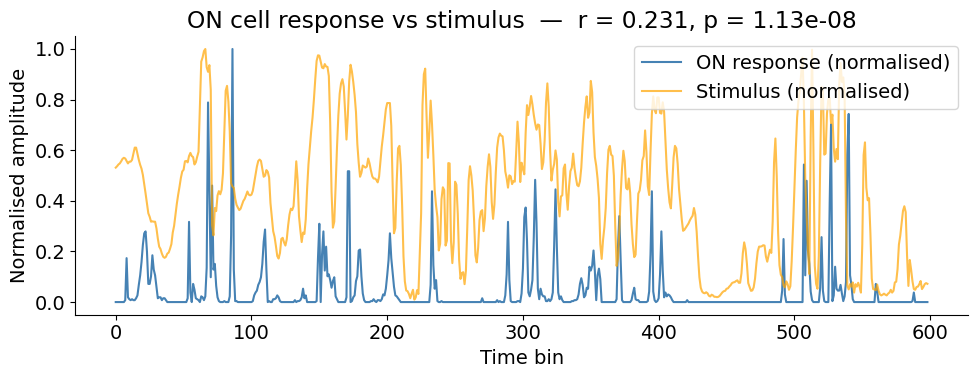

Pearson r = 0.2306
p-value   = 0.0000


In [ ]:
from scipy.stats import pearsonr

# Average response across repetitions
mean_on = binnedON.mean(axis=0)   # shape (T,)

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean_on / mean_on.max(), label='ON response (normalised)', color='steelblue')
ax.plot(stim / stim.max(),       label='Stimulus (normalised)',     color='orange', alpha=0.7)

# annotate
ax.set_xlabel('Time bin')
ax.set_ylabel('Normalised amplitude')
ax.set_title(f'ON cell response vs stimulus  —  r = {r:.3f}, p = {p:.2e}')
ax.legend()
plt.tight_layout()
plt.show()

# Pearson correlation with stimulus
r, p = pearsonr(mean_on, stim)
print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p:.4f}")

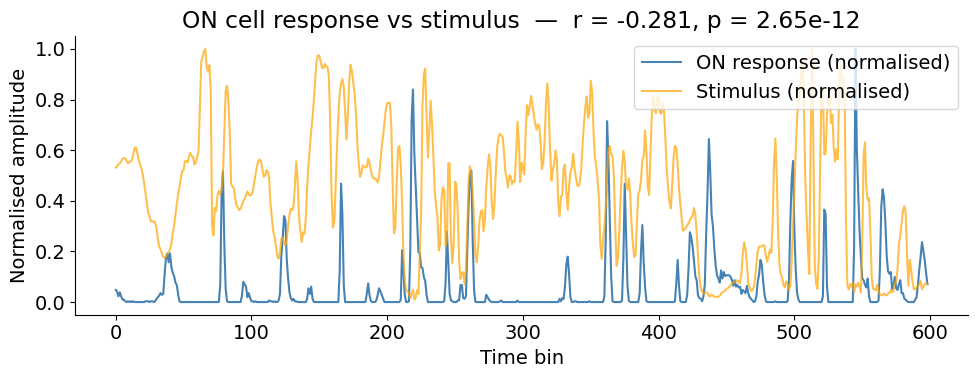

Pearson r = -0.2806
p-value   = 0.0000


In [ ]:
# Average response across repetitions
mean_off = binnedOFF.mean(axis=0)   # shape (T,)

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean_off / mean_off.max(), label='ON response (normalised)', color='steelblue')
ax.plot(stim / stim.max(),       label='Stimulus (normalised)',     color='orange', alpha=0.7)

# annotate
ax.set_xlabel('Time bin')
ax.set_ylabel('Normalised amplitude')
ax.set_title(f'ON cell response vs stimulus  —  r = {r:.3f}, p = {p:.2e}')
ax.legend()
plt.tight_layout()
plt.show()

# Pearson correlation with stimulus
r, p = pearsonr(mean_off, stim)
print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p:.4f}")